In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
gamma = 1.4
Cp = 1005
T1 = 300
P1 = 101325
T3 = 1400
r = 10

In [3]:
T2 = T1 * r**((gamma - 1)/gamma)
P2 = P1 * r
P3 = P2
T4 = T3 * (1/r)**((gamma - 1)/gamma)
P4 = P1

print(f"T1 = {T1} K,    P1 = {P1} Pa")
print(f"T2 = {T2:.2f} K,  P2 = {P2:.2f} Pa")
print(f"T3 = {T3} K,  P3 = {P3:.2f} Pa")
print(f"T4 = {T4:.2f} K,  P4 = {P4:.2f} Pa")

T1 = 300 K,    P1 = 101325 Pa
T2 = 579.21 K,  P2 = 1013250.00 Pa
T3 = 1400 K,  P3 = 1013250.00 Pa
T4 = 725.13 K,  P4 = 101325.00 Pa


In [4]:
Q_in = Cp * (T3 - T2)
Q_out = Cp * (T4 - T1)
W_turbine = Cp * (T3 - T4)
W_compressor = Cp * (T2 - T1)
W_net = Q_in - Q_out
Efficiency = W_net / Q_in
BWR = W_compressor / W_turbine

In [5]:
print("=" * 45)
print("       Brayton Cycle Analysis")
print("=" * 45)
print("State Conditions:")
print(f"  State 1: T1 = {T1} K,       P1 = {P1} Pa")
print(f"  State 2: T2 = {T2:.2f} K,  P2 = {P2:.2f} Pa")
print(f"  State 3: T3 = {T3} K,    P3 = {P3:.2f} Pa")
print(f"  State 4: T4 = {T4:.2f} K,  P4 = {P4:.2f} Pa")
print()
print("Performance:")
print(f"  Heat Added (Q_in)          = {Q_in:.2f} J/kg")
print(f"  Heat Rejected (Q_out)      = {Q_out:.2f} J/kg")
print(f"  Work by Turbine            = {W_turbine:.2f} J/kg")
print(f"  Work by Compressor         = {W_compressor:.2f} J/kg")
print(f"  Net Work (W_net)           = {W_net:.2f} J/kg")
print(f"  Thermal Efficiency         = {Efficiency*100:.2f} %")
print(f"  Back Work Ratio            = {BWR*100:.2f} %")
print("=" * 45)

       Brayton Cycle Analysis
State Conditions:
  State 1: T1 = 300 K,       P1 = 101325 Pa
  State 2: T2 = 579.21 K,  P2 = 1013250.00 Pa
  State 3: T3 = 1400 K,    P3 = 1013250.00 Pa
  State 4: T4 = 725.13 K,  P4 = 101325.00 Pa

Performance:
  Heat Added (Q_in)          = 824894.63 J/kg
  Heat Rejected (Q_out)      = 427252.09 J/kg
  Work by Turbine            = 678247.91 J/kg
  Work by Compressor         = 280605.37 J/kg
  Net Work (W_net)           = 397642.55 J/kg
  Thermal Efficiency         = 48.21 %
  Back Work Ratio            = 41.37 %


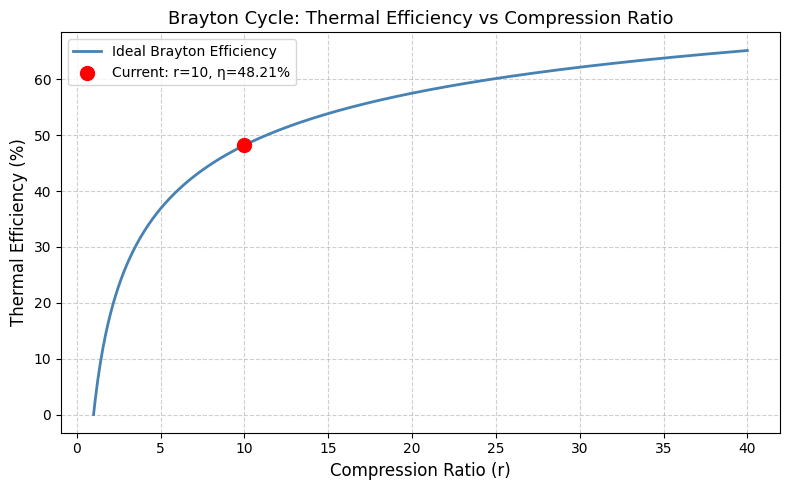

In [6]:
r_array = np.linspace(1, 40, 500)
eta_array = 1 - (1 / (r_array ** ((gamma - 1) / gamma)))

r_current = r
eta_current = Efficiency

plt.figure(figsize=(8, 5))
plt.plot(r_array, eta_array * 100,
         color='steelblue',
         linewidth=2,
         label='Ideal Brayton Efficiency')
plt.scatter(r_current, eta_current * 100,
            color='red',
            s=100,
            zorder=5,
            label=f'Current: r={r_current}, η={eta_current*100:.2f}%')
plt.xlabel('Compression Ratio (r)', fontsize=12)
plt.ylabel('Thermal Efficiency (%)', fontsize=12)
plt.title('Brayton Cycle: Thermal Efficiency vs Compression Ratio', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

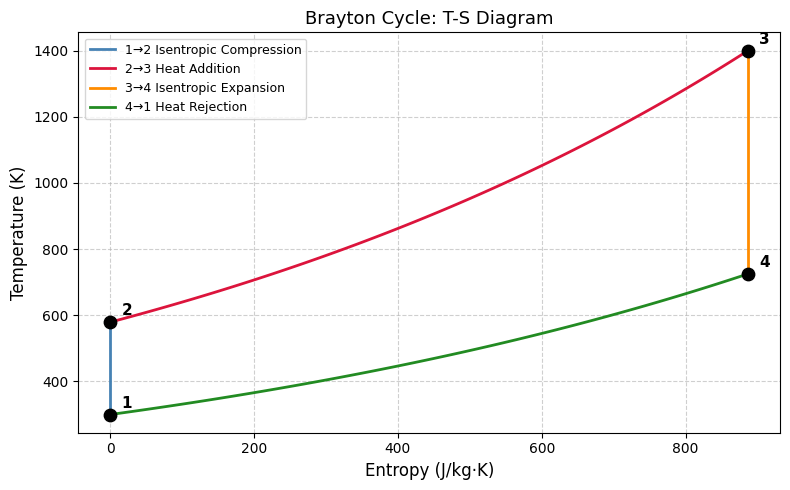

In [7]:
S1 = 0
S2 = S1
S3 = S2 + Cp * np.log(T3/T2)
S4 = S3

T_12 = np.linspace(T1, T2, 100)
S_12 = np.full(100, S1)

S_23 = np.linspace(S2, S3, 100)
T_23 = T2 * np.exp(S_23 / Cp)

T_34 = np.linspace(T3, T4, 100)
S_34 = np.full(100, S3)

S_41 = np.linspace(S4, S1, 100)
T_41 = T4 * np.exp((S_41 - S4) / Cp)

plt.figure(figsize=(8, 5))
plt.plot(S_12, T_12, color='steelblue',   linewidth=2, label='1→2 Isentropic Compression')
plt.plot(S_23, T_23, color='crimson',     linewidth=2, label='2→3 Heat Addition')
plt.plot(S_34, T_34, color='darkorange',  linewidth=2, label='3→4 Isentropic Expansion')
plt.plot(S_41, T_41, color='forestgreen', linewidth=2, label='4→1 Heat Rejection')

states_S = [S1, S2, S3, S4]
states_T = [T1, T2, T3, T4]
labels   = ['1', '2', '3', '4']

plt.scatter(states_S, states_T, color='black', s=80, zorder=5)
for i, label in enumerate(labels):
    plt.annotate(label,
                 (states_S[i], states_T[i]),
                 textcoords="offset points",
                 xytext=(8, 5),
                 fontsize=11,
                 fontweight='bold')

plt.xlabel('Entropy (J/kg·K)', fontsize=12)
plt.ylabel('Temperature (K)', fontsize=12)
plt.title('Brayton Cycle: T-S Diagram', fontsize=13)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()